In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
import time

# Настройка отображения графиков
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12


In [ ]:
print("=== ЗАГРУЗКА ДАННЫХ WINE ===")
wine = load_wine()
X_wine = wine.data
y_wine = wine.target
feature_names_wine = wine.feature_names
target_names_wine = wine.target_names

print("Описание набора данных:")
print(wine.DESCR[:500])
print(f"\nКоличество образцов: {X_wine.shape[0]}")
print(f"Количество признаков: {X_wine.shape[1]}")
print(f"Названия признаков: {list(feature_names_wine)}")
print(f"Названия классов: {list(target_names_wine)}")

=== ЗАГРУЗКА ДАННЫХ WINE ===
Описание набора данных:
.. _wine_dataset:

Wine recognition dataset
------------------------

**Data Set Characteristics:**

:Number of Instances: 178
:Number of Attributes: 13 numeric, predictive attributes and the class
:Attribute Information:
    - Alcohol
    - Malic acid
    - Ash
    - Alcalinity of ash
    - Magnesium
    - Total phenols
    - Flavanoids
    - Nonflavanoid phenols
    - Proanthocyanins
    - Color intensity
    - Hue
    - OD280/OD315 of diluted wines
    - Proline
    - class:
        - class_0

Количество образцов: 178
Количество признаков: 13
Названия признаков: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
Названия классов: [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]


In [ ]:
df_wine = pd.DataFrame(X_wine, columns=feature_names_wine)
df_wine['target_class'] = y_wine
df_wine['class_name'] = df_wine['target_class'].apply(lambda x: target_names_wine[x])

print("\nПервые 5 строк данных:")
print(df_wine.head())

print("\nРаспределение по классам:")
print(df_wine['class_name'].value_counts())



Первые 5 строк данных:
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proli

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_wine, y_wine, test_size=0.2, random_state=42, stratify=y_wine
)

print(f"\nРазмеры выборок:")
print(f"Обучающая: {X_train.shape}")
print(f"Тестовая: {X_test.shape}")


Размеры выборок:
Обучающая: (142, 13)
Тестовая: (36, 13)


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Масштабирование признаков завершено")

Масштабирование признаков завершено


In [ ]:
class KNearestNeighbours:
    def __init__(self, n_neighbours=5):
        """
        Конструктор класса
        n_neighbours: количество ближайших соседей (k)
        """
        self.n_neighbours = n_neighbours

    def fit(self, X, y):
        """
        Сохраняет обучающие данные
        X: array-like, shape (n_samples, n_features)
        y: array-like, shape (n_samples,)
        """
        self.X_train = np.array(X)
        self.y_train = np.array(y)
        print(f"Обучение завершено. Сохранено {self.X_train.shape[0]} образцов")

    def euclidean_distance(self, a, b):
        """Вычисление евклидова расстояния между двумя точками"""
        return np.sqrt(np.sum((a - b) ** 2))

    def predict(self, X):
        """
        Предсказание классов для входных данных
        X: array-like, shape (n_samples, n_features)
        Returns: array, shape (n_samples,)
        """
        X_test = np.array(X)
        predictions = []

        print(f"Начало предсказания для {X_test.shape[0]} образцов...")

        for i, x in enumerate(X_test):
            # Вычисление расстояний до всех точек обучающей выборки
            distances = []
            for j, x_train in enumerate(self.X_train):
                dist = self.euclidean_distance(x, x_train)
                distances.append((dist, self.y_train[j]))

            # Сортировка по расстоянию и выбор k ближайших соседей
            distances.sort(key=lambda x: x[0])
            nearest_neighbours = distances[:self.n_neighbours]

            # Голосование: выбор наиболее частого класса
            neighbour_classes = [neighbour[1] for neighbour in nearest_neighbours]
            prediction = max(set(neighbour_classes), key=neighbour_classes.count)
            predictions.append(prediction)

            # Прогресс для больших наборов
            if (i + 1) % 10 == 0:
                print(f"Обработано {i + 1}/{X_test.shape[0]} образцов")

        return np.array(predictions)

In [ ]:
print("\n--- Тестирование собственной реализации k-NN ---")

# Используем часть данных для быстрого тестирования
X_train_small = X_train_scaled[:100]  # Первые 100 образцов
y_train_small = y_train[:100]
X_test_small = X_test_scaled[:20]     # Первые 20 тестовых образцов
y_test_small = y_test[:20]

print(f"Размеры данных для тестирования:")
print(f"Обучающая выборка: {X_train_small.shape}")
print(f"Тестовая выборка: {X_test_small.shape}")

# Создание и обучение модели
my_knn = KNearestNeighbours(n_neighbours=5)
my_knn.fit(X_train_small, y_train_small)

# Предсказание
start_time = time.time()
y_pred_my = my_knn.predict(X_test_small)
my_time = time.time() - start_time

# Оценка точности
my_accuracy = accuracy_score(y_test_small, y_pred_my)

print(f"\nРезультаты собственной реализации:")
print(f"Точность: {my_accuracy:.4f}")
print(f"Время предсказания: {my_time:.2f} сек")
print(f"Предсказанные классы: {y_pred_my}")
print(f"Истинные классы: {y_test_small}")


--- Тестирование собственной реализации k-NN ---
Размеры данных для тестирования:
Обучающая выборка: (100, 13)
Тестовая выборка: (20, 13)
Обучение завершено. Сохранено 100 образцов
Начало предсказания для 20 образцов...
Обработано 10/20 образцов
Обработано 20/20 образцов

Результаты собственной реализации:
Точность: 0.9000
Время предсказания: 0.03 сек
Предсказанные классы: [0 1 0 1 1 0 0 1 1 2 1 2 0 1 0 1 1 0 1 0]
Истинные классы: [0 2 0 1 1 0 0 1 1 2 1 2 0 2 0 1 1 0 1 0]


In [ ]:
print("\n--- Сравнение с sklearn реализацией ---")

sklearn_knn = KNeighborsClassifier(n_neighbors=5)
sklearn_knn.fit(X_train_small, y_train_small)

start_time = time.time()
y_pred_sklearn = sklearn_knn.predict(X_test_small)
sklearn_time = time.time() - start_time

sklearn_accuracy = accuracy_score(y_test_small, y_pred_sklearn)

print(f"Результаты sklearn реализации:")
print(f"Точность: {sklearn_accuracy:.4f}")
print(f"Время предсказания: {sklearn_time:.4f} сек")
print(f"Предсказанные классы: {y_pred_sklearn}")

print(f"\nСравнение:")
print(f"Разница в точности: {abs(my_accuracy - sklearn_accuracy):.4f}")
print(f"Отношение времени (моя/sklearn): {my_time/sklearn_time:.2f}")


--- Сравнение с sklearn реализацией ---
Результаты sklearn реализации:
Точность: 0.9000
Время предсказания: 0.0066 сек
Предсказанные классы: [0 1 0 1 1 0 0 1 1 2 1 2 0 1 0 1 1 0 1 0]

Сравнение:
Разница в точности: 0.0000
Отношение времени (моя/sklearn): 4.03


In [ ]:
print("\n" + "="*50)
print("ВИЗУАЛИЗАЦИЯ ДАННЫХ WINE")
print("="*50)

# Выбираем признаки для визуализации (как указано в задании)
feature1 = 'od280/od315_of_diluted_wines'
feature2 = 'flavanoids'

print(f"Выбранные признаки для визуализации:")
print(f"1. {feature1}")
print(f"2. {feature2}")

# Проверяем, что признаки существуют в данных
if feature1 in df_wine.columns and feature2 in df_wine.columns:
    print("Признаки найдены в данных!")
else:
    print("Ошибка: указанные признаки не найдены!")
    print("Доступные признаки:", list(df_wine.columns[:-2]))


ВИЗУАЛИЗАЦИЯ ДАННЫХ WINE
Выбранные признаки для визуализации:
1. od280/od315_of_diluted_wines
2. flavanoids
Признаки найдены в данных!


In [ ]:
data_c0 = df_wine[df_wine['target_class'] == 0]
data_c1 = df_wine[df_wine['target_class'] == 1]
data_c2 = df_wine[df_wine['target_class'] == 2]

print(f"Количество образцов по классам:")
print(f"Class 0 ({target_names_wine[0]}): {len(data_c0)}")
print(f"Class 1 ({target_names_wine[1]}): {len(data_c1)}")
print(f"Class 2 ({target_names_wine[2]}): {len(data_c2)}")

Количество образцов по классам:
Class 0 (class_0): 59
Class 1 (class_1): 71
Class 2 (class_2): 48


In [ ]:
x0, y0 = data_c0[feature1], data_c0[feature2]
x1, y1 = data_c1[feature1], data_c1[feature2]
x2, y2 = data_c2[feature1], data_c2[feature2]

print(f"\nСтатистика по выбранным признакам:")
print(f"{feature1}: min={df_wine[feature1].min():.2f}, max={df_wine[feature1].max():.2f}, mean={df_wine[feature1].mean():.2f}")
print(f"{feature2}: min={df_wine[feature2].min():.2f}, max={df_wine[feature2].max():.2f}, mean={df_wine[feature2].mean():.2f}")


Статистика по выбранным признакам:
od280/od315_of_diluted_wines: min=1.27, max=4.00, mean=2.61
flavanoids: min=0.34, max=5.08, mean=2.03


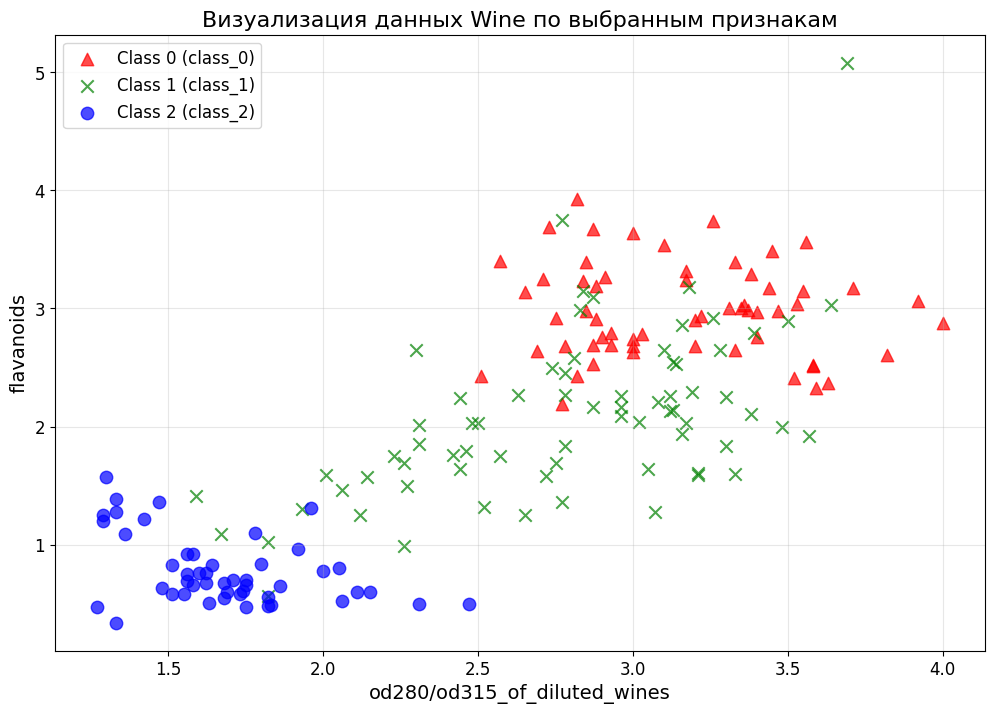

In [ ]:
plt.figure(figsize=(12, 8))

# Точечная диаграмма с разными маркерами (как в задании)
plt.scatter(x0, y0, marker='^', s=80, alpha=0.7,
           label=f'Class 0 ({target_names_wine[0]})', color='red')
plt.scatter(x1, y1, marker='x', s=80, alpha=0.7,
           label=f'Class 1 ({target_names_wine[1]})', color='green')
plt.scatter(x2, y2, marker='o', s=80, alpha=0.7,
           label=f'Class 2 ({target_names_wine[2]})', color='blue')

plt.xlabel(feature1, fontsize=14)
plt.ylabel(feature2, fontsize=14)
plt.title('Визуализация данных Wine по выбранным признакам', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

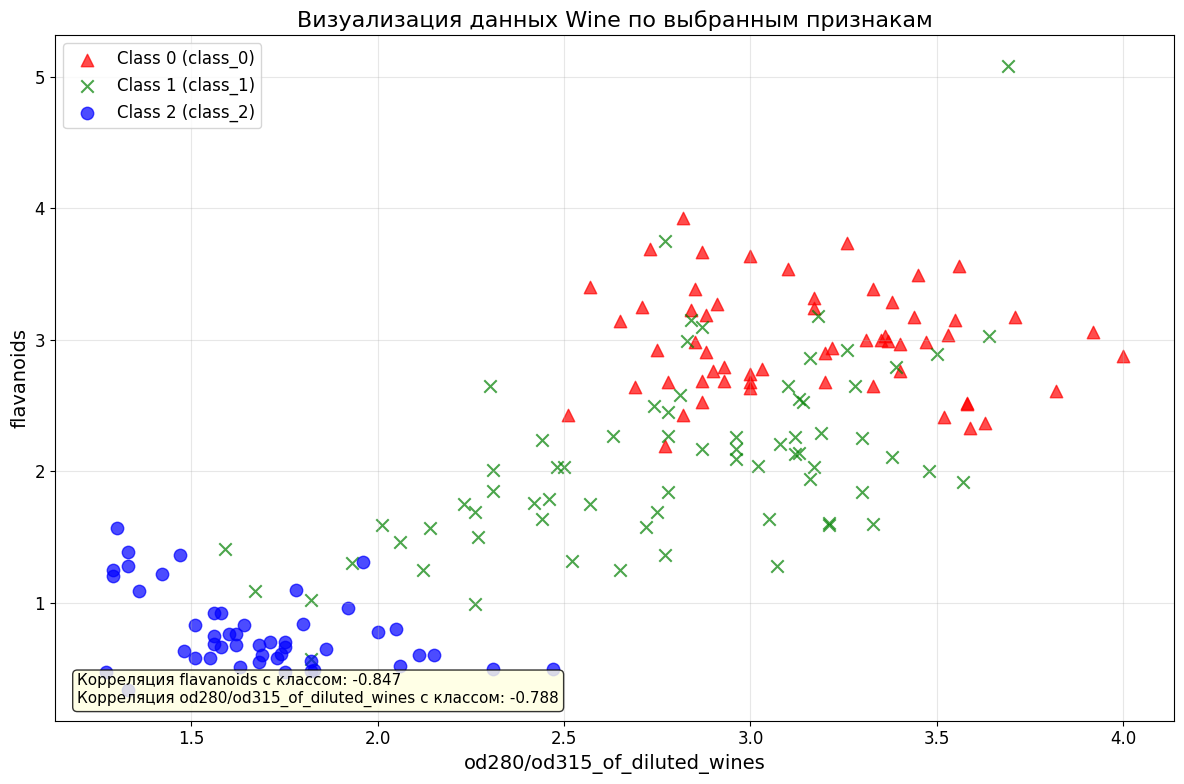

In [ ]:
corr_feature1 = np.corrcoef(df_wine[feature1], df_wine['target_class'])[0, 1]
corr_feature2 = np.corrcoef(df_wine[feature2], df_wine['target_class'])[0, 1]

# Построение графика
plt.figure(figsize=(12, 8))

# Точечная диаграмма с разными маркерами (как в задании)
plt.scatter(x0, y0, marker='^', s=80, alpha=0.7,
           label=f'Class 0 ({target_names_wine[0]})', color='red')
plt.scatter(x1, y1, marker='x', s=80, alpha=0.7,
           label=f'Class 1 ({target_names_wine[1]})', color='green')
plt.scatter(x2, y2, marker='o', s=80, alpha=0.7,
           label=f'Class 2 ({target_names_wine[2]})', color='blue')

plt.xlabel(feature1, fontsize=14)
plt.ylabel(feature2, fontsize=14)
plt.title('Визуализация данных Wine по выбранным признакам', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

plt.text(0.02, 0.02,
        f'Корреляция {feature2} с классом: {corr_feature2:.3f}\n'
        f'Корреляция {feature1} с классом: {corr_feature1:.3f}',
        transform=plt.gca().transAxes, fontsize=11,
        verticalalignment='bottom',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.show()

In [ ]:
print("\n" + "="*50)
print("АНАЛИЗ ВЫБРАННЫХ ПРИЗНАКОВ")
print("="*50)

print(f"\nПРИЗНАК 1: {feature1}")
print("Описание: Отношение оптических плотностей OD280/OD315 разбавленных вин")
print("Химическая значимость: Показатель концентрации белков и полифенолов в вине")
print("Влияние на качество: Высокие значения обычно ассоциируются с лучшим качеством")
print(f"Корреляция с целевой переменной: {corr_feature1:.3f}")

print(f"\nПРИЗНАК 2: {feature2}")
print("Описание: Содержание флавоноидов")
print("Химическая значимость: Флавоноиды - важные антиоксиданты, влияющие на вкус, цвет и срок хранения вина")
print("Влияние на качество: Высокое содержание флавоноидов обычно указывает на лучшее качество вина")
print(f"Корреляция с целевой переменной: {corr_feature2:.3f}")


АНАЛИЗ ВЫБРАННЫХ ПРИЗНАКОВ

ПРИЗНАК 1: od280/od315_of_diluted_wines
Описание: Отношение оптических плотностей OD280/OD315 разбавленных вин
Химическая значимость: Показатель концентрации белков и полифенолов в вине
Влияние на качество: Высокие значения обычно ассоциируются с лучшим качеством
Корреляция с целевой переменной: -0.788

ПРИЗНАК 2: flavanoids
Описание: Содержание флавоноидов
Химическая значимость: Флавоноиды - важные антиоксиданты, влияющие на вкус, цвет и срок хранения вина
Влияние на качество: Высокое содержание флавоноидов обычно указывает на лучшее качество вина
Корреляция с целевой переменной: -0.847


In [ ]:
print("\n--- Проверка важности признаков для классификации ---")

# Получаем индексы выбранных признаков
feature1_idx = list(feature_names_wine).index(feature1)
feature2_idx = list(feature_names_wine).index(feature2)

# Создаем матрицу признаков только с двумя выбранными признаками
X_wine_selected = X_wine[:, [feature1_idx, feature2_idx]]

print(f"Используемые признаки: {feature1}, {feature2}")
print(f"Размерность данных после отбора признаков: {X_wine_selected.shape}")


--- Проверка важности признаков для классификации ---
Используемые признаки: od280/od315_of_diluted_wines, flavanoids
Размерность данных после отбора признаков: (178, 2)


In [ ]:
X_train_sel, X_test_sel, y_train_sel, y_test_sel = train_test_split(
    X_wine_selected, y_wine, test_size=0.2, random_state=42, stratify=y_wine
)

scaler_sel = StandardScaler()
X_train_sel_scaled = scaler_sel.fit_transform(X_train_sel)
X_test_sel_scaled = scaler_sel.transform(X_test_sel)

# Обучение модели на двух признаках
knn_sel = KNeighborsClassifier(n_neighbors=5)
knn_sel.fit(X_train_sel_scaled, y_train_sel)
y_pred_sel = knn_sel.predict(X_test_sel_scaled)
accuracy_sel = accuracy_score(y_test_sel, y_pred_sel)

# Обучение модели на всех признаках для сравнения
knn_all = KNeighborsClassifier(n_neighbors=5)
knn_all.fit(X_train_scaled, y_train)
y_pred_all = knn_all.predict(X_test_scaled)
accuracy_all = accuracy_score(y_test, y_pred_all)

print(f"\nСравнение точности классификации:")
print(f"Точность на ДВУХ признаках ({feature1}, {feature2}): {accuracy_sel:.4f}")
print(f"Точность на ВСЕХ признаках (13): {accuracy_all:.4f}")
print(f"Разница в точности: {accuracy_all - accuracy_sel:.4f}")


Сравнение точности классификации:
Точность на ДВУХ признаках (od280/od315_of_diluted_wines, flavanoids): 0.8611
Точность на ВСЕХ признаках (13): 0.9722
Разница в точности: 0.1111


In [ ]:
print(classification_report(y_test_sel, y_pred_sel, target_names=target_names_wine))

              precision    recall  f1-score   support

     class_0       0.79      0.92      0.85        12
     class_1       0.91      0.71      0.80        14
     class_2       0.91      1.00      0.95        10

    accuracy                           0.86        36
   macro avg       0.87      0.88      0.87        36
weighted avg       0.87      0.86      0.86        36



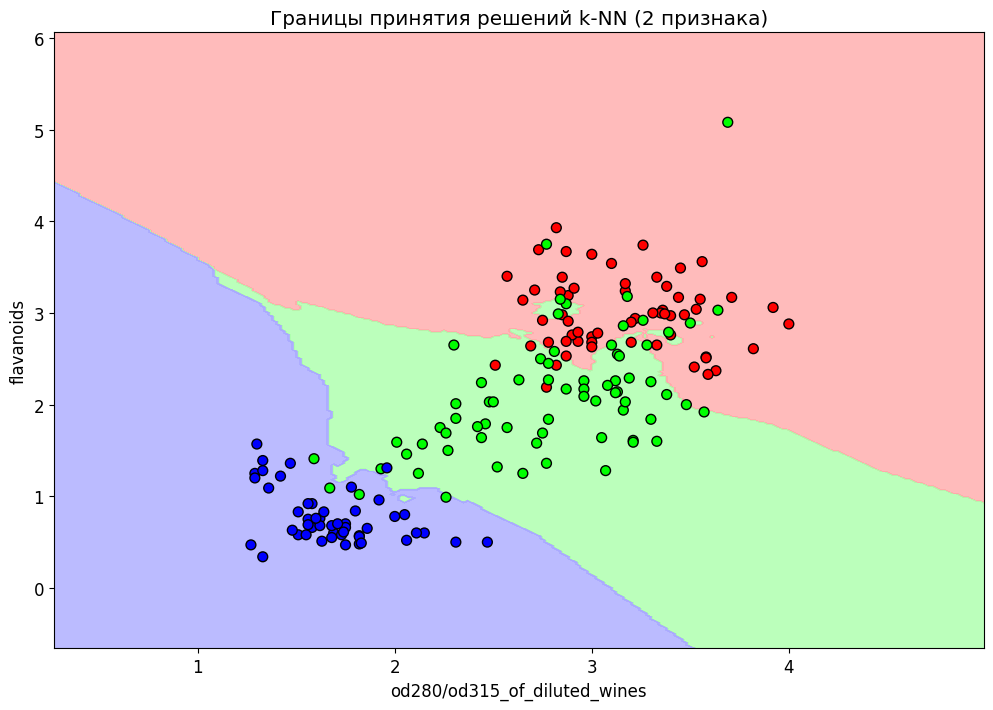

In [ ]:
from matplotlib.colors import ListedColormap

# Создаем mesh grid для визуализации границ
h = 0.02  # step size in the mesh
x_min, x_max = X_wine_selected[:, 0].min() - 1, X_wine_selected[:, 0].max() + 1
y_min, y_max = X_wine_selected[:, 1].min() - 1, X_wine_selected[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# Масштабируем mesh grid
mesh_points = np.c_[xx.ravel(), yy.ravel()]
mesh_points_scaled = scaler_sel.transform(mesh_points)

# Предсказания для mesh grid
Z = knn_sel.predict(mesh_points_scaled)
Z = Z.reshape(xx.shape)

# Создаем цветовую карту
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

# Визуализация границ решений
plt.figure(figsize=(12, 8))
plt.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.8)

# Добавляем исходные точки
plt.scatter(X_wine_selected[:, 0], X_wine_selected[:, 1], c=y_wine,
           cmap=cmap_bold, edgecolor='black', s=50)
plt.xlabel(feature1)
plt.ylabel(feature2)
plt.title('Границы принятия решений k-NN (2 признака)')
plt.show()